In [1]:
!pip install numpy matplotlib pandas tqdm scipy scikit-learn networkx --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [3]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_20782/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_20782/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


In [4]:
data = data.drop(data[data["position"] == "team"].index) 

In [5]:

gameids = data[data["teamid"].isna()]["gameid"].unique()
data = data[~data["gameid"].isin(gameids)]

In [6]:
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)

In [7]:
data[data["league"] == "WLDs"]

,gameid,datacompleteness,league,year,split,playoffs,date,game,patch,participantid,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25


In [8]:
# For every game id, get the 2 teams that play against each other, and create an edge between them in the graph.
import networkx as nx
from tqdm import tqdm

G = nx.Graph()
for game_id in tqdm(data["gameid"].unique()):
    teams = data[data["gameid"] == game_id]["teamid"].unique()
    if len(teams) == 2:
        G.add_edge(teams[0], teams[1])

100%|██████████| 7196/7196 [00:27<00:00, 257.90it/s]


In [9]:
#Get region for team id (use the leagues.json transformation from league to region)
import json

with open('utils/leagues.json', 'r') as f:
    leagues = json.load(f)

teamid_to_region = {}
data["region"] = data["league"].map(lambda x: leagues.get(x, "Unknown"))
data

/tmp/ipykernel_20782/4097772714.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["region"] = data["league"].map(lambda x: leagues.get(x, "Unknown"))


,gameid,datacompleteness,league,year,split,playoffs,date,game,patch,participantid,...,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25,region
0,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,1,...,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0,EU
1,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,2,...,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0,EU
2,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,3,...,-1552.0,-2465.0,-41.0,1.0,0.0,2.0,1.0,5.0,1.0,EU
3,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,4,...,-2613.0,-1156.0,-6.0,1.0,1.0,2.0,6.0,2.0,0.0,EU
4,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,5,...,-662.0,-734.0,18.0,0.0,2.0,2.0,0.0,8.0,0.0,EU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118925,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,6,...,1809.0,1467.0,-12.0,5.0,1.0,4.0,1.0,4.0,7.0,KR
118926,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,7,...,-188.0,2855.0,47.0,0.0,9.0,2.0,2.0,5.0,4.0,KR
118927,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,8,...,787.0,888.0,-23.0,9.0,4.0,1.0,4.0,3.0,1.0,KR
118928,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,9,...,814.0,-348.0,15.0,3.0,9.0,1.0,2.0,4.0,2.0,KR


In [10]:
# Get the adj_matrix from the graph as np
adj_matrix = nx.to_numpy_array(G)
print(adj_matrix.shape)

(317, 317)


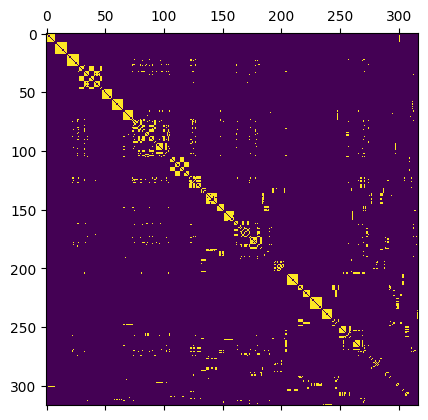

In [11]:
plt.matshow(adj_matrix)

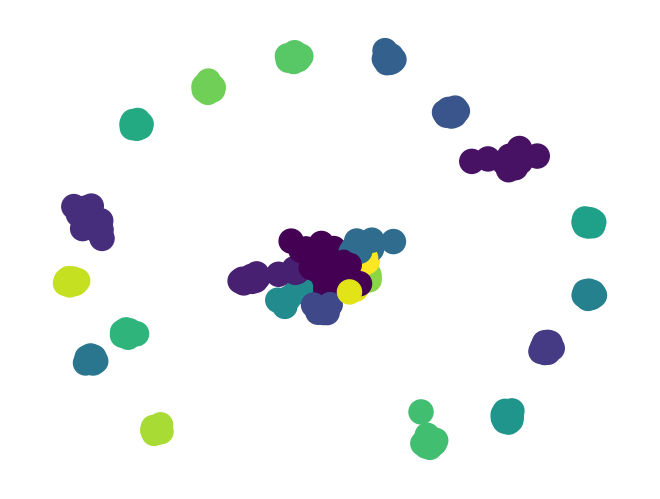

In [12]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

def plot_graph_communities(G, communities):
    color_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            color_map[node] = i

    colors = [color_map[node] for node in G.nodes()]
    nx.draw(G, node_color=colors, with_labels=False)
    plt.show()

plot_graph_communities(G, communities)

In [13]:
from sklearn.cluster import SpectralClustering, spectral_clustering
#sc = SpectralClustering(n_clusters=7, affinity='precomputed', assign_labels='discretize')
#labels = sc.fit_predict(adj_matrix)
labels = spectral_clustering(n_clusters=5, affinity=adj_matrix, assign_labels='discretize')

print(labels)

# Make teamid -> label dataframe
df_teams = pd.DataFrame({
    "teamid": list(G.nodes()),
    "label": labels
})

# Add the region per team id using this dump .first
#teamid_to_region = data.groupby("teamid")["region"].first()
# Take the most common region instead of first
teamid_to_name = data.groupby("teamid")["teamname"].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
teamid_to_region = data.groupby("teamid")["region"].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
teamid_to_league = data.groupby("teamid")["league"].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
df_teams["region"] = df_teams["teamid"].map(teamid_to_region)
df_teams["league"] = df_teams["teamid"].map(teamid_to_league)
# For each label, show the distribution of regions using value counts
for label in sorted(df_teams["label"].unique()):
    print(f"Label {label}:")
    print(df_teams[df_teams["label"] == label]["region"].value_counts())
    print()

/home/vlad/venv/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[4 4 4 4 4 4 4 4 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0
 1 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 0 1 1 1 1 4 4 4 4 4 4 4 4 4 4 0 0
 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4
 4 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 4 4 4 4 4 4 4 4 4 4 1 1 1 1 1 1 1
 1 1 1 3 3 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0
 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 1 1 1 1 1 1 4 4 1 1 0 0 0 1 1 4 0
 1 0 3 3 3 4 1 4 4 0 0 0 0 3 0 0 1 0 0 0 1]
Label 0:
region
EU      146
APAC      8
Name: count, dtype: int64

Label 1:
region
KR      30
LAT     19
APAC    15
EU      11
JP       9
Name: count, dtype: int64

Label 2:
region
APAC    9
Name: count, dtype: int64

Label 3:
region
NA     21
LAT     9
Name: count, dtype: int64

Label 4:
region
EU     28
LAT    12
Name: count, dtype: int64



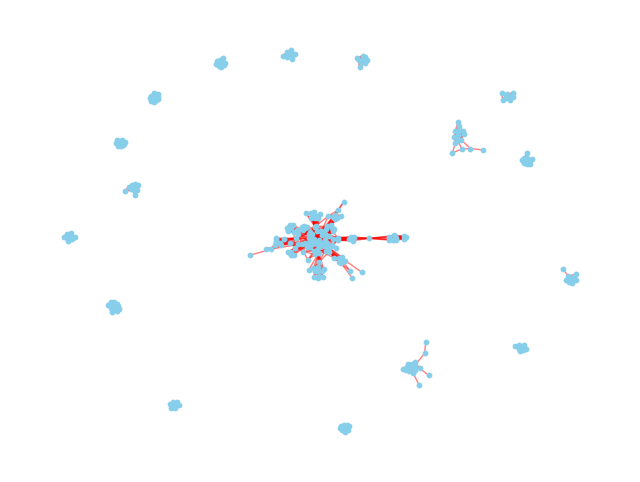

In [ ]:
# 1. Define the layout (positions)
pos = nx.spring_layout(G, seed=42) 

# 2. Draw components separately for better control
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=10, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, edge_color="red")
#nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

plt.axis("off") # Hide the axis for a cleaner look
plt.show()

In [15]:
from pyvis.network import Network
import networkx as nx

# 1. Create a Pyvis network object
net = Network(height="600px", width="100%", bgcolor="#222222", font_color="white", notebook=True)

# 2. Load the NetworkX graph into Pyvis
net.from_nx(G)

# 3. Update the labels using your mapping
for node in net.nodes:
    node_id = node['id']
    # Use .get() to avoid errors if a teamid is missing from your map
    node['label'] = teamid_to_name.get(node_id, str(node_id)) + " (" + teamid_to_league.get(node_id, str(node_id)) + " - " + teamid_to_region.get(node_id, "Unknown") + ")"

net.toggle_physics(True)
net.show("outputs/interactive_graph.html")

outputs/interactive_graph.html


In [16]:
data[data["teamname"] == "Gen.G"].value_counts("league")

league
LCK    585
Name: count, dtype: int64